# Figure 8: Learning top-down weights

In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
import h5py

import EIANN.utils as ut
import EIANN.plot as pt
from EIANN.generate_figures import *

pt.update_plot_defaults()
root_dir = ut.get_project_root()

%load_ext autoreload
%autoreload 2

In [2]:
figure_name = "Fig8_WB_alignment_FA_bpLike_BTSP"
model_list1 = ["bpLike_WT_hebbdend", "bpLike_fixedTD_hebbdend", "bpLike_TCWN_hebbdend"]
model_list2 = ["BTSP_WT_hebbdend", "BTSP_fixedTD_hebbdend", "BTSP_TCWN_hebbdend"]
all_models = model_list1 + model_list2

model_dict_all = load_model_dict()

generate_hdf5_all_seeds(all_models, model_dict_all, recompute=None, variables_to_save = ['test_accuracy_history', 'angle_vs_bp', 'feedback_weight_angle_history'])

Generating plots for LDS
Generating plots for Fixed random B (LDS)
Generating plots for Learned B: TCH (LDS)
Generating plots for Symmetric B=W (BTSP)
Generating plots for Fixed random B (BTSP)
Generating plots for Learned B: TCH (BTSP)


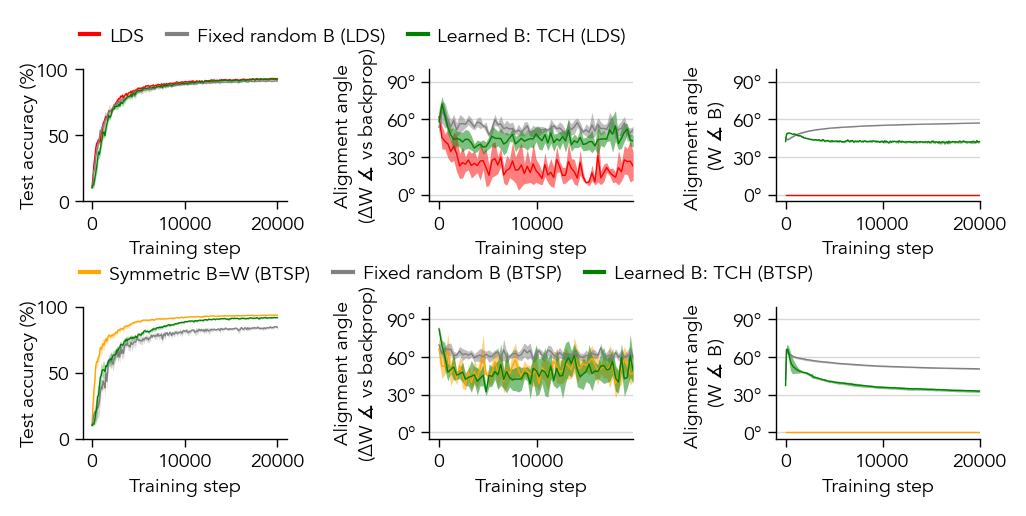

In [6]:
fig = plt.figure(figsize=(6.5, 2.4))
axes = gs.GridSpec(nrows=2, ncols=3, figure=fig,                    
                    left=0.28,right=0.97,
                    top=0.92, bottom = 0.15,
                    wspace=0.7, hspace=0.8)
ax_accuracy1 = fig.add_subplot(axes[0,0])
ax_angle_vs_BP1 = fig.add_subplot(axes[0,1])
ax_FB_angle1 = fig.add_subplot(axes[0,2])
ax_accuracy2 = fig.add_subplot(axes[1,0])
ax_angle_vs_BP2 = fig.add_subplot(axes[1,1])
ax_FB_angle2 = fig.add_subplot(axes[1,2])

model_dict_all["bpLike_WT_hebbdend"]["label"] = "LDS"

for i, model_key in enumerate(all_models):
    model_dict = model_dict_all[model_key]
    network_name = model_dict['config'].split('.')[0]
    hdf5_path = root_dir + f"/EIANN/data/model_hdf5_plot_data/plot_data_{network_name}.h5"
    with h5py.File(hdf5_path, 'r') as f:
        data_dict = f[network_name]
        print(f"Generating plots for {model_dict['label']}")
        if model_key in model_list1:
            ax_accuracy = ax_accuracy1
            ax_angle_vs_BP = ax_angle_vs_BP1
            ax_FB_angle = ax_FB_angle1
        if model_key in model_list2:
            ax_accuracy = ax_accuracy2
            ax_angle_vs_BP = ax_angle_vs_BP2
            ax_FB_angle = ax_FB_angle2
        plot_accuracy_all_seeds(data_dict, model_dict, ax=ax_accuracy)
        plot_angle_vs_bp_all_seeds(data_dict, model_dict, ax=ax_angle_vs_BP, error='std')
        plot_angle_FB_all_seeds(data_dict, model_dict, ax=ax_FB_angle, error='std')

legend = ax_accuracy1.legend(ncol=3, bbox_to_anchor=(-0.1, 1.45), loc='upper left')
for line in legend.get_lines():
    line.set_linewidth(1.5)
legend = ax_accuracy2.legend(ncol=3, bbox_to_anchor=(-0.1, 1.45), loc='upper left')
for line in legend.get_lines():
    line.set_linewidth(1.5)

fig.savefig(f"{root_dir}/EIANN/figures/{figure_name}.png", dpi=300)
fig.savefig(f"{root_dir}/EIANN/figures/{figure_name}.svg", dpi=300)